Saved as: cone_region_clean.png


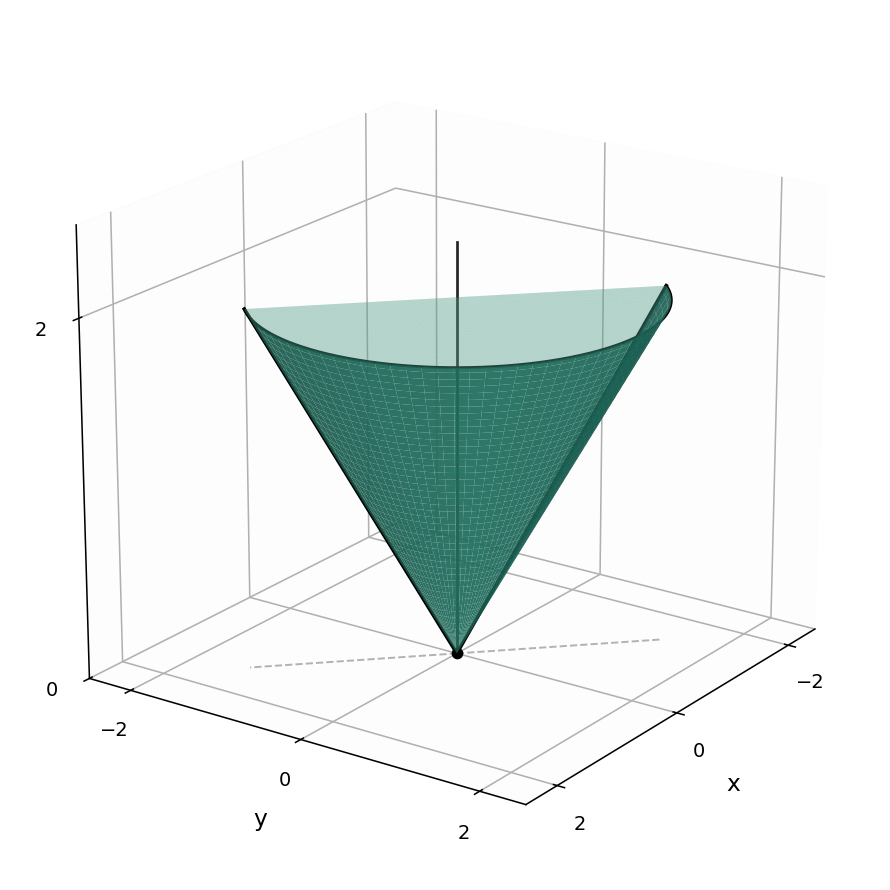

In [1]:
# ============================================================
# CHALMERS-STYLE 3D CONE REGION VISUALIZATION
# Region:
#   inside z = sqrt(x^2 + y^2)
#   bounded above by z = a
#   angular slice determined by x + y = 0
#
# Output:
#   Clean mathematical 3D figure only
#   No theory text on the image
# ============================================================

# =========================
# 1) Imports
# =========================
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

# =========================
# 2) Figure quality settings
# =========================
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300

# =========================
# 3) Problem parameter
# =========================
a = 2.0   # top plane z = a

# =========================
# 4) Angular region from x + y = 0
#    cos(theta) + sin(theta) = 0
#    => theta = -pi/4 to 3pi/4  (half-space slice)
# =========================
theta_min = -np.pi / 4
theta_max =  3 * np.pi / 4

# Resolution controls
n_r = 180
n_theta = 260

# =========================
# 5) Cone surface: z = r
#    Region shown only on theta interval [theta_min, theta_max]
# =========================
r = np.linspace(0, a, n_r)
theta = np.linspace(theta_min, theta_max, n_theta)

R, TH = np.meshgrid(r, theta)

X_cone = R * np.cos(TH)
Y_cone = R * np.sin(TH)
Z_cone = R

# =========================
# 6) Top disk: z = a
#    Only over same angular sector
# =========================
R_top, TH_top = np.meshgrid(r, theta)

X_top = R_top * np.cos(TH_top)
Y_top = R_top * np.sin(TH_top)
Z_top = np.full_like(X_top, a)

# =========================
# 7) Boundary planes of the angular sector
#    theta = theta_min and theta = theta_max
#    These correspond to the cutting vertical plane x+y=0.
#
#    For each boundary, create a ruled surface:
#    r in [0,a], z in [r,a]
# =========================
rb = np.linspace(0, a, 180)
zb = np.linspace(0, a, 180)

RB, ZB = np.meshgrid(rb, zb)

# Mask so that z >= r (inside the cone region up to z=a)
mask = ZB >= RB

# Boundary 1: theta = theta_min
X_b1 = RB * np.cos(theta_min)
Y_b1 = RB * np.sin(theta_min)
Z_b1 = ZB.copy()

X_b1 = np.where(mask, X_b1, np.nan)
Y_b1 = np.where(mask, Y_b1, np.nan)
Z_b1 = np.where(mask, Z_b1, np.nan)

# Boundary 2: theta = theta_max
X_b2 = RB * np.cos(theta_max)
Y_b2 = RB * np.sin(theta_max)
Z_b2 = ZB.copy()

X_b2 = np.where(mask, X_b2, np.nan)
Y_b2 = np.where(mask, Y_b2, np.nan)
Z_b2 = np.where(mask, Z_b2, np.nan)

# =========================
# 8) Bottom edge lines on z=0 from apex to make the wedge clearer
# =========================
edge_r = np.linspace(0, a, 200)

# On the cone surface the "edge" is from apex upward, but to visually
# show the sector opening, we also draw guide lines in the base plane z=0.
x_edge1_base = edge_r * np.cos(theta_min)
y_edge1_base = edge_r * np.sin(theta_min)
z_edge1_base = np.zeros_like(edge_r)

x_edge2_base = edge_r * np.cos(theta_max)
y_edge2_base = edge_r * np.sin(theta_max)
z_edge2_base = np.zeros_like(edge_r)

# Cone boundary lines (actual cone edges in the sector)
x_edge1_cone = edge_r * np.cos(theta_min)
y_edge1_cone = edge_r * np.sin(theta_min)
z_edge1_cone = edge_r

x_edge2_cone = edge_r * np.cos(theta_max)
y_edge2_cone = edge_r * np.sin(theta_max)
z_edge2_cone = edge_r

# Top arc
theta_arc = np.linspace(theta_min, theta_max, 300)
x_arc = a * np.cos(theta_arc)
y_arc = a * np.sin(theta_arc)
z_arc = np.full_like(theta_arc, a)

# =========================
# 9) Create figure
# =========================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# -------------------------
# 10) Plot main surfaces
# -------------------------

# Cone surface
ax.plot_surface(
    X_cone, Y_cone, Z_cone,
    color="#1f6f5f",
    alpha=0.92,
    linewidth=0,
    antialiased=True,
    shade=True
)

# Top cap (z = a)
ax.plot_surface(
    X_top, Y_top, Z_top,
    color="#3d8b7d",
    alpha=0.30,
    linewidth=0,
    antialiased=True,
    shade=False
)

# Angular boundary surface 1
ax.plot_surface(
    X_b1, Y_b1, Z_b1,
    color="#7fc8a9",
    alpha=0.18,
    linewidth=0,
    antialiased=True,
    shade=False
)

# Angular boundary surface 2
ax.plot_surface(
    X_b2, Y_b2, Z_b2,
    color="#7fc8a9",
    alpha=0.18,
    linewidth=0,
    antialiased=True,
    shade=False
)

# -------------------------
# 11) Draw crisp boundary lines
# -------------------------
line_color = "black"

# Cone side edges
ax.plot(x_edge1_cone, y_edge1_cone, z_edge1_cone, color=line_color, lw=1.8)
ax.plot(x_edge2_cone, y_edge2_cone, z_edge2_cone, color=line_color, lw=1.8)

# Top circular arc
ax.plot(x_arc, y_arc, z_arc, color=line_color, lw=1.5)

# Top straight edges connecting arc ends to apex-top corners
ax.plot(
    [0, a*np.cos(theta_min)],
    [0, a*np.sin(theta_min)],
    [0, a],
    color=line_color, lw=0.0
)
ax.plot(
    [0, a*np.cos(theta_max)],
    [0, a*np.sin(theta_max)],
    [0, a],
    color=line_color, lw=0.0
)

# Base guide lines
ax.plot(x_edge1_base, y_edge1_base, z_edge1_base, color="gray", lw=1.0, ls="--", alpha=0.6)
ax.plot(x_edge2_base, y_edge2_base, z_edge2_base, color="gray", lw=1.0, ls="--", alpha=0.6)

# Vertical axis through apex for visual reference
ax.plot([0, 0], [0, 0], [0, a*1.15], color="black", lw=1.4, alpha=0.85)

# Apex point
ax.scatter([0], [0], [0], color="black", s=25)

# =========================
# 12) Axis limits / view / proportions
# =========================
pad = 0.25 * a
ax.set_xlim(-a - pad, a + pad)
ax.set_ylim(-a - pad, a + pad)
ax.set_zlim(0, a + pad)

# Equal-ish visual proportions
ax.set_box_aspect((1, 1, 0.9))

# Camera angle
ax.view_init(elev=20, azim=35)

# =========================
# 13) Minimal clean styling
# =========================
ax.set_xlabel("x", labelpad=8, fontsize=12)
ax.set_ylabel("y", labelpad=8, fontsize=12)
ax.set_zlabel("z", labelpad=8, fontsize=12)

# Remove title intentionally (you asked no theory text)
# ax.set_title("")

# Light pane colors for a cleaner mathematical look
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.set_alpha(0.08)

# Soft grid
ax.grid(True, alpha=0.25)

# Optional ticks
ax.set_xticks([-2, 0, 2] if a >= 2 else [-a, 0, a])
ax.set_yticks([-2, 0, 2] if a >= 2 else [-a, 0, a])
ax.set_zticks([0, a])

# =========================
# 14) Save high-resolution image
# =========================
output_name = "cone_region_clean.png"
plt.savefig(output_name, bbox_inches="tight", facecolor="white")
print(f"Saved as: {output_name}")

# =========================
# 15) Show figure
# =========================
plt.show()

Saved: cone_region_academic.png
Saved: cone_region_academic.pdf


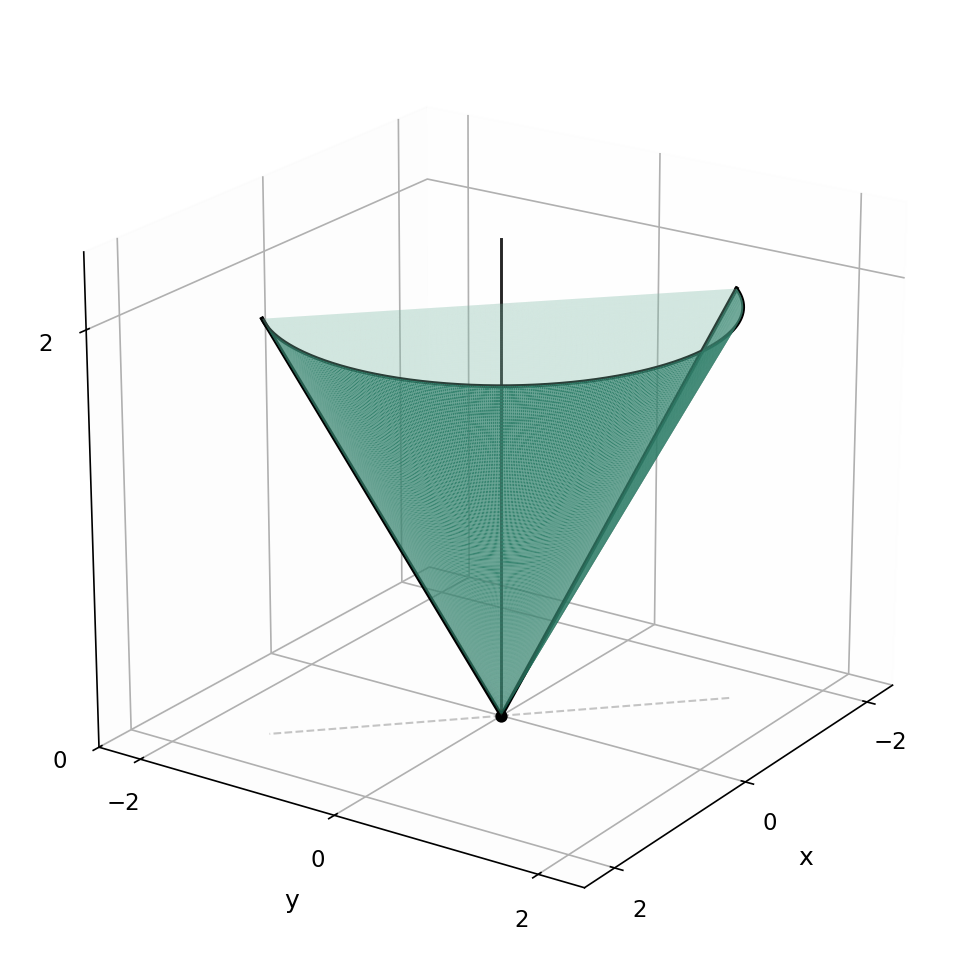

In [2]:
# ============================================================
# PREMIUM ACADEMIC 3D VISUALIZATION
# Region:
#   U = solid inside z = sqrt(x^2+y^2),
#       bounded by z = a,
#       restricted to angular sector from x + y = 0
#
# Goal:
#   Clean academic visualization only
#   No mathematical derivation text on figure
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ------------------------------------------------------------
# 1) Global render settings
# ------------------------------------------------------------
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 400
plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 12

# ------------------------------------------------------------
# 2) Problem parameter
# ------------------------------------------------------------
a = 2.0

# Angular sector determined by x + y = 0:
# theta in [-pi/4, 3pi/4]
theta_min = -np.pi / 4
theta_max =  3 * np.pi / 4

# ------------------------------------------------------------
# 3) Mesh resolution
# ------------------------------------------------------------
n_r = 240
n_theta = 360
n_side_r = 220
n_side_z = 220

# ------------------------------------------------------------
# 4) Main cone surface: z = r
# ------------------------------------------------------------
r = np.linspace(0, a, n_r)
theta = np.linspace(theta_min, theta_max, n_theta)

R, TH = np.meshgrid(r, theta)

X_cone = R * np.cos(TH)
Y_cone = R * np.sin(TH)
Z_cone = R

# ------------------------------------------------------------
# 5) Top cap: z = a over the same angular sector
# ------------------------------------------------------------
R_top, TH_top = np.meshgrid(r, theta)
X_top = R_top * np.cos(TH_top)
Y_top = R_top * np.sin(TH_top)
Z_top = np.full_like(X_top, a)

# ------------------------------------------------------------
# 6) Side boundary surfaces at theta = theta_min and theta_max
#    Each side is:
#       0 <= r <= a
#       r <= z <= a
# ------------------------------------------------------------
rb = np.linspace(0, a, n_side_r)
zb = np.linspace(0, a, n_side_z)
RB, ZB = np.meshgrid(rb, zb)

mask = ZB >= RB

# Boundary 1
X_b1 = RB * np.cos(theta_min)
Y_b1 = RB * np.sin(theta_min)
Z_b1 = ZB.copy()

X_b1 = np.where(mask, X_b1, np.nan)
Y_b1 = np.where(mask, Y_b1, np.nan)
Z_b1 = np.where(mask, Z_b1, np.nan)

# Boundary 2
X_b2 = RB * np.cos(theta_max)
Y_b2 = RB * np.sin(theta_max)
Z_b2 = ZB.copy()

X_b2 = np.where(mask, X_b2, np.nan)
Y_b2 = np.where(mask, Y_b2, np.nan)
Z_b2 = np.where(mask, Z_b2, np.nan)

# ------------------------------------------------------------
# 7) Important boundary curves
# ------------------------------------------------------------
edge_r = np.linspace(0, a, 400)

# Cone edges of the wedge
x_edge1 = edge_r * np.cos(theta_min)
y_edge1 = edge_r * np.sin(theta_min)
z_edge1 = edge_r

x_edge2 = edge_r * np.cos(theta_max)
y_edge2 = edge_r * np.sin(theta_max)
z_edge2 = edge_r

# Top arc
theta_arc = np.linspace(theta_min, theta_max, 500)
x_arc = a * np.cos(theta_arc)
y_arc = a * np.sin(theta_arc)
z_arc = np.full_like(theta_arc, a)

# Base guide rays (optional, subtle)
x_base1 = edge_r * np.cos(theta_min)
y_base1 = edge_r * np.sin(theta_min)
z_base1 = np.zeros_like(edge_r)

x_base2 = edge_r * np.cos(theta_max)
y_base2 = edge_r * np.sin(theta_max)
z_base2 = np.zeros_like(edge_r)

# ------------------------------------------------------------
# 8) Shading / lighting setup for the cone
# ------------------------------------------------------------
# LightSource helps the surface look less flat.
ls = LightSource(azdeg=315, altdeg=35)

# Use the cone height for shading intensity
# Normalize Z for stable shading
Z_norm = (Z_cone - Z_cone.min()) / (Z_cone.max() - Z_cone.min() + 1e-12)

# Base cone color (deep academic green)
base_rgb = np.zeros((*Z_norm.shape, 3))
base_rgb[..., 0] = 0.12
base_rgb[..., 1] = 0.42
base_rgb[..., 2] = 0.34

# Blend shading with base color
cone_facecolors = ls.shade_rgb(base_rgb, Z_norm)

# ------------------------------------------------------------
# 9) Figure and axes
# ------------------------------------------------------------
fig = plt.figure(figsize=(9.2, 8.2))
ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# 10) Plot surfaces
# ------------------------------------------------------------

# Cone surface
ax.plot_surface(
    X_cone, Y_cone, Z_cone,
    facecolors=cone_facecolors,
    rstride=1, cstride=1,
    linewidth=0,
    antialiased=True,
    shade=False,
    alpha=0.98
)

# Top cap (semi-transparent)
ax.plot_surface(
    X_top, Y_top, Z_top,
    color="#6fae9a",
    alpha=0.22,
    linewidth=0,
    antialiased=True,
    shade=False
)

# Side boundary surface 1
ax.plot_surface(
    X_b1, Y_b1, Z_b1,
    color="#9ed3c0",
    alpha=0.16,
    linewidth=0,
    antialiased=True,
    shade=False
)

# Side boundary surface 2
ax.plot_surface(
    X_b2, Y_b2, Z_b2,
    color="#9ed3c0",
    alpha=0.16,
    linewidth=0,
    antialiased=True,
    shade=False
)

# ------------------------------------------------------------
# 11) Boundary curves for crisp mathematical definition
# ------------------------------------------------------------
edge_color = "black"

# Cone edges
ax.plot(x_edge1, y_edge1, z_edge1, color=edge_color, lw=2.0)
ax.plot(x_edge2, y_edge2, z_edge2, color=edge_color, lw=2.0)

# Top arc
ax.plot(x_arc, y_arc, z_arc, color=edge_color, lw=1.8)

# Base guide rays
ax.plot(x_base1, y_base1, z_base1, color="gray", lw=1.0, ls="--", alpha=0.45)
ax.plot(x_base2, y_base2, z_base2, color="gray", lw=1.0, ls="--", alpha=0.45)

# z-axis guide
ax.plot([0, 0], [0, 0], [0, a * 1.15], color="black", lw=1.4, alpha=0.85)

# Apex
ax.scatter([0], [0], [0], color="black", s=24)

# ------------------------------------------------------------
# 12) Axis ranges and aspect
# ------------------------------------------------------------
pad_xy = 0.22 * a
pad_z = 0.18 * a

ax.set_xlim(-a - pad_xy, a + pad_xy)
ax.set_ylim(-a - pad_xy, a + pad_xy)
ax.set_zlim(0, a + pad_z)

# Balanced 3D proportions
ax.set_box_aspect((1, 1, 0.9))

# Camera view
ax.view_init(elev=21, azim=34)

# ------------------------------------------------------------
# 13) Academic styling
# ------------------------------------------------------------
ax.set_xlabel("x", labelpad=8)
ax.set_ylabel("y", labelpad=8)
ax.set_zlabel("z", labelpad=8)

# Minimal ticks
ax.set_xticks([-2, 0, 2] if a >= 2 else [-a, 0, a])
ax.set_yticks([-2, 0, 2] if a >= 2 else [-a, 0, a])
ax.set_zticks([0, a])

# Clean panes
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.set_alpha(0.06)

# Soft grid
ax.grid(True, alpha=0.22)

# Remove any title (no theory text on figure)
# ax.set_title("")

# ------------------------------------------------------------
# 14) Save outputs
# ------------------------------------------------------------
png_name = "cone_region_academic.png"
pdf_name = "cone_region_academic.pdf"

plt.savefig(png_name, bbox_inches="tight", facecolor="white")
plt.savefig(pdf_name, bbox_inches="tight", facecolor="white")

print(f"Saved: {png_name}")
print(f"Saved: {pdf_name}")

# ------------------------------------------------------------
# 15) Show
# ------------------------------------------------------------
plt.show()

3D Visualization of a Triple Integral Region Bounded by a Cone and a Plane

This project visualizes the three-dimensional integration region associated with the triple integral

I = ∭_U e^(sqrt(x^2 + y^2)) dV

where U is the solid inside the cone

z = sqrt(x^2 + y^2),

bounded above by the plane

z = a, a > 0,

and restricted by the vertical plane

x + y = 0.

Geometric interpretation of the region

The surface

z = sqrt(x^2 + y^2)

represents a right circular cone opening upward with vertex at the origin. In cylindrical coordinates, since

r = sqrt(x^2 + y^2),

the cone equation becomes

z = r.

The plane

z = a

cuts the cone horizontally and creates the top boundary of the solid. At z = a, the cone intersects the plane in a circle of radius a. Therefore, the region is the solid portion of the cone from the apex up to the height z = a.

The additional condition

x + y = 0

defines a vertical plane passing through the origin. In cylindrical coordinates,

x = r cos(theta),
y = r sin(theta),

so the condition becomes

r(cos(theta) + sin(theta)) = 0.

For r ≠ 0, this gives

cos(theta) + sin(theta) = 0
tan(theta) = -1.

Hence the angular limits are

theta = -pi/4 and theta = 3pi/4.

This means the solid is not the full cone segment, but an angular sector of it with angular width pi.

Why cylindrical coordinates are used

The geometry of the region and the integrand both naturally suggest cylindrical coordinates. The expressions

sqrt(x^2 + y^2) and z = sqrt(x^2 + y^2)

simplify immediately when we use

x = r cos(theta),
y = r sin(theta),
z = z.

Under this transformation,

sqrt(x^2 + y^2) = r,

and the volume element becomes

dV = r dz dr dtheta.

Therefore, the integrand

e^(sqrt(x^2 + y^2))

becomes

e^r,

and together with the Jacobian factor r, the integrand in cylindrical coordinates becomes

e^r * r.

Bounds of the integration region

The cone gives the lower z-boundary:

z = r.

The top plane gives the upper z-boundary:

z = a.

So for a fixed radius r,

r <= z <= a.

Since the largest radius occurs at the top circle z = a, the radial coordinate satisfies

0 <= r <= a.

The angular restriction from x + y = 0 gives

-pi/4 <= theta <= 3pi/4.

Thus the region in cylindrical coordinates is

U = { (r, theta, z) : 0 <= r <= a, r <= z <= a, -pi/4 <= theta <= 3pi/4 }.

Triple integral in cylindrical form

Using these bounds, the integral becomes

I = ∫[theta=-pi/4 to 3pi/4] ∫[r=0 to a] ∫[z=r to a] e^r * r dz dr dtheta.

Since e^r * r does not depend on z, integrating first with respect to z gives

∫[z=r to a] e^r * r dz = (a - r) r e^r.

So the integral reduces to

I = ∫[theta=-pi/4 to 3pi/4] ∫[r=0 to a] (a - r) r e^r dr dtheta.

The theta integral contributes only the angular width

3pi/4 - (-pi/4) = pi.

Hence,

I = pi ∫[r=0 to a] (a - r) r e^r dr.

Expanding the integrand,

(a - r) r e^r = a r e^r - r^2 e^r.

So,

I = pi [ a∫(r e^r)dr - ∫(r^2 e^r)dr ] from 0 to a.

Evaluating these terms by integration by parts leads to the closed-form result

I = pi [ (a - 2)e^a + a + 2 ].

Final result

The value of the triple integral is

I = pi((a - 2)e^a + a + 2).

Visualization objective of the project

The purpose of this project is not only to compute the integral analytically, but also to represent the geometry of the integration region in 3D. The visualization highlights:

the cone surface z = sqrt(x^2 + y^2),
the top boundary plane z = a,
the angular sector determined by x + y = 0,
and the exact solid region over which the triple integral is defined.

This makes the relationship between the analytic setup and the geometric domain much clearer, especially when working with cylindrical-coordinate triple integrals in multivariable calculus.